# Heart Disease Prediction — Machine Learning Project
1. **k-Nearest Neighbors**
2. **Decision Tree**
3. **AdaBoost**
4. **Neural Network**

## Setup

In [65]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # make `src` importable

import importlib
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import data_loader as dl
from src import metrics, evaluation as ev, plots
from src.preprocessing import train_test_split, StandardScaler, kfold_indices
from src.models.knn import KNNClassifier
from src.models.decision_tree import DecisionTreeClassifier
from src.models.adaboost import AdaBoostClassifier
from src.models import neural_network as _nn_mod
from src.models.neural_network import NeuralNetwork

# Reload src modules so any file edits take effect without a kernel restart.
importlib.reload(ev)
importlib.reload(_nn_mod)
from src.models.neural_network import NeuralNetwork  # re-import after reload

SEED = 42
np.random.seed(SEED)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print("environment ready")


environment ready


## Loading the data and describing the dataset

In [66]:
raw_df = dl.load_data(dedup=False)
df = dl.load_data(dedup=True)  # deduplicate
X, y, feature_names = dl.get_Xy(df)

summary = dl.dataset_summary()
print("Raw rows:        ", summary["n_rows_raw"])
print("Unique rows:     ", summary["n_rows_unique"])
print("Duplicate rows:  ", summary["n_duplicates"])
print("Missing values:  ", summary["n_missing"])
print("Target (unique): ", summary["target_balance_unique"])
df.head()

Raw rows:         1025
Unique rows:      302
Duplicate rows:   723
Missing values:   0
Target (unique):  {1: 164, 0: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.000,54.421,9.048,29.000,48.000,55.500,61.000,77.000
sex,302.000,0.682,0.466,0.000,0.000,1.000,1.000,1.000
cp,302.000,0.964,1.032,0.000,0.000,1.000,2.000,3.000
trestbps,302.000,131.603,17.563,94.000,120.000,130.000,140.000,200.000
chol,302.000,246.500,51.753,126.000,211.000,240.500,274.750,564.000
fbs,302.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,302.000,0.526,0.526,0.000,0.000,1.000,1.000,2.000
thalach,302.000,149.570,22.904,71.000,133.250,152.500,166.000,202.000
exang,302.000,0.328,0.470,0.000,0.000,0.000,1.000,1.000
oldpeak,302.000,1.043,1.161,0.000,0.000,0.800,1.600,6.200


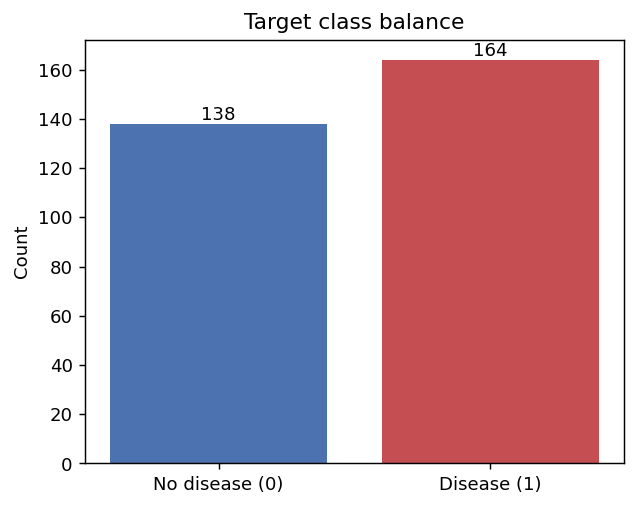

In [68]:
display(Image(plots.plot_class_balance(y)))

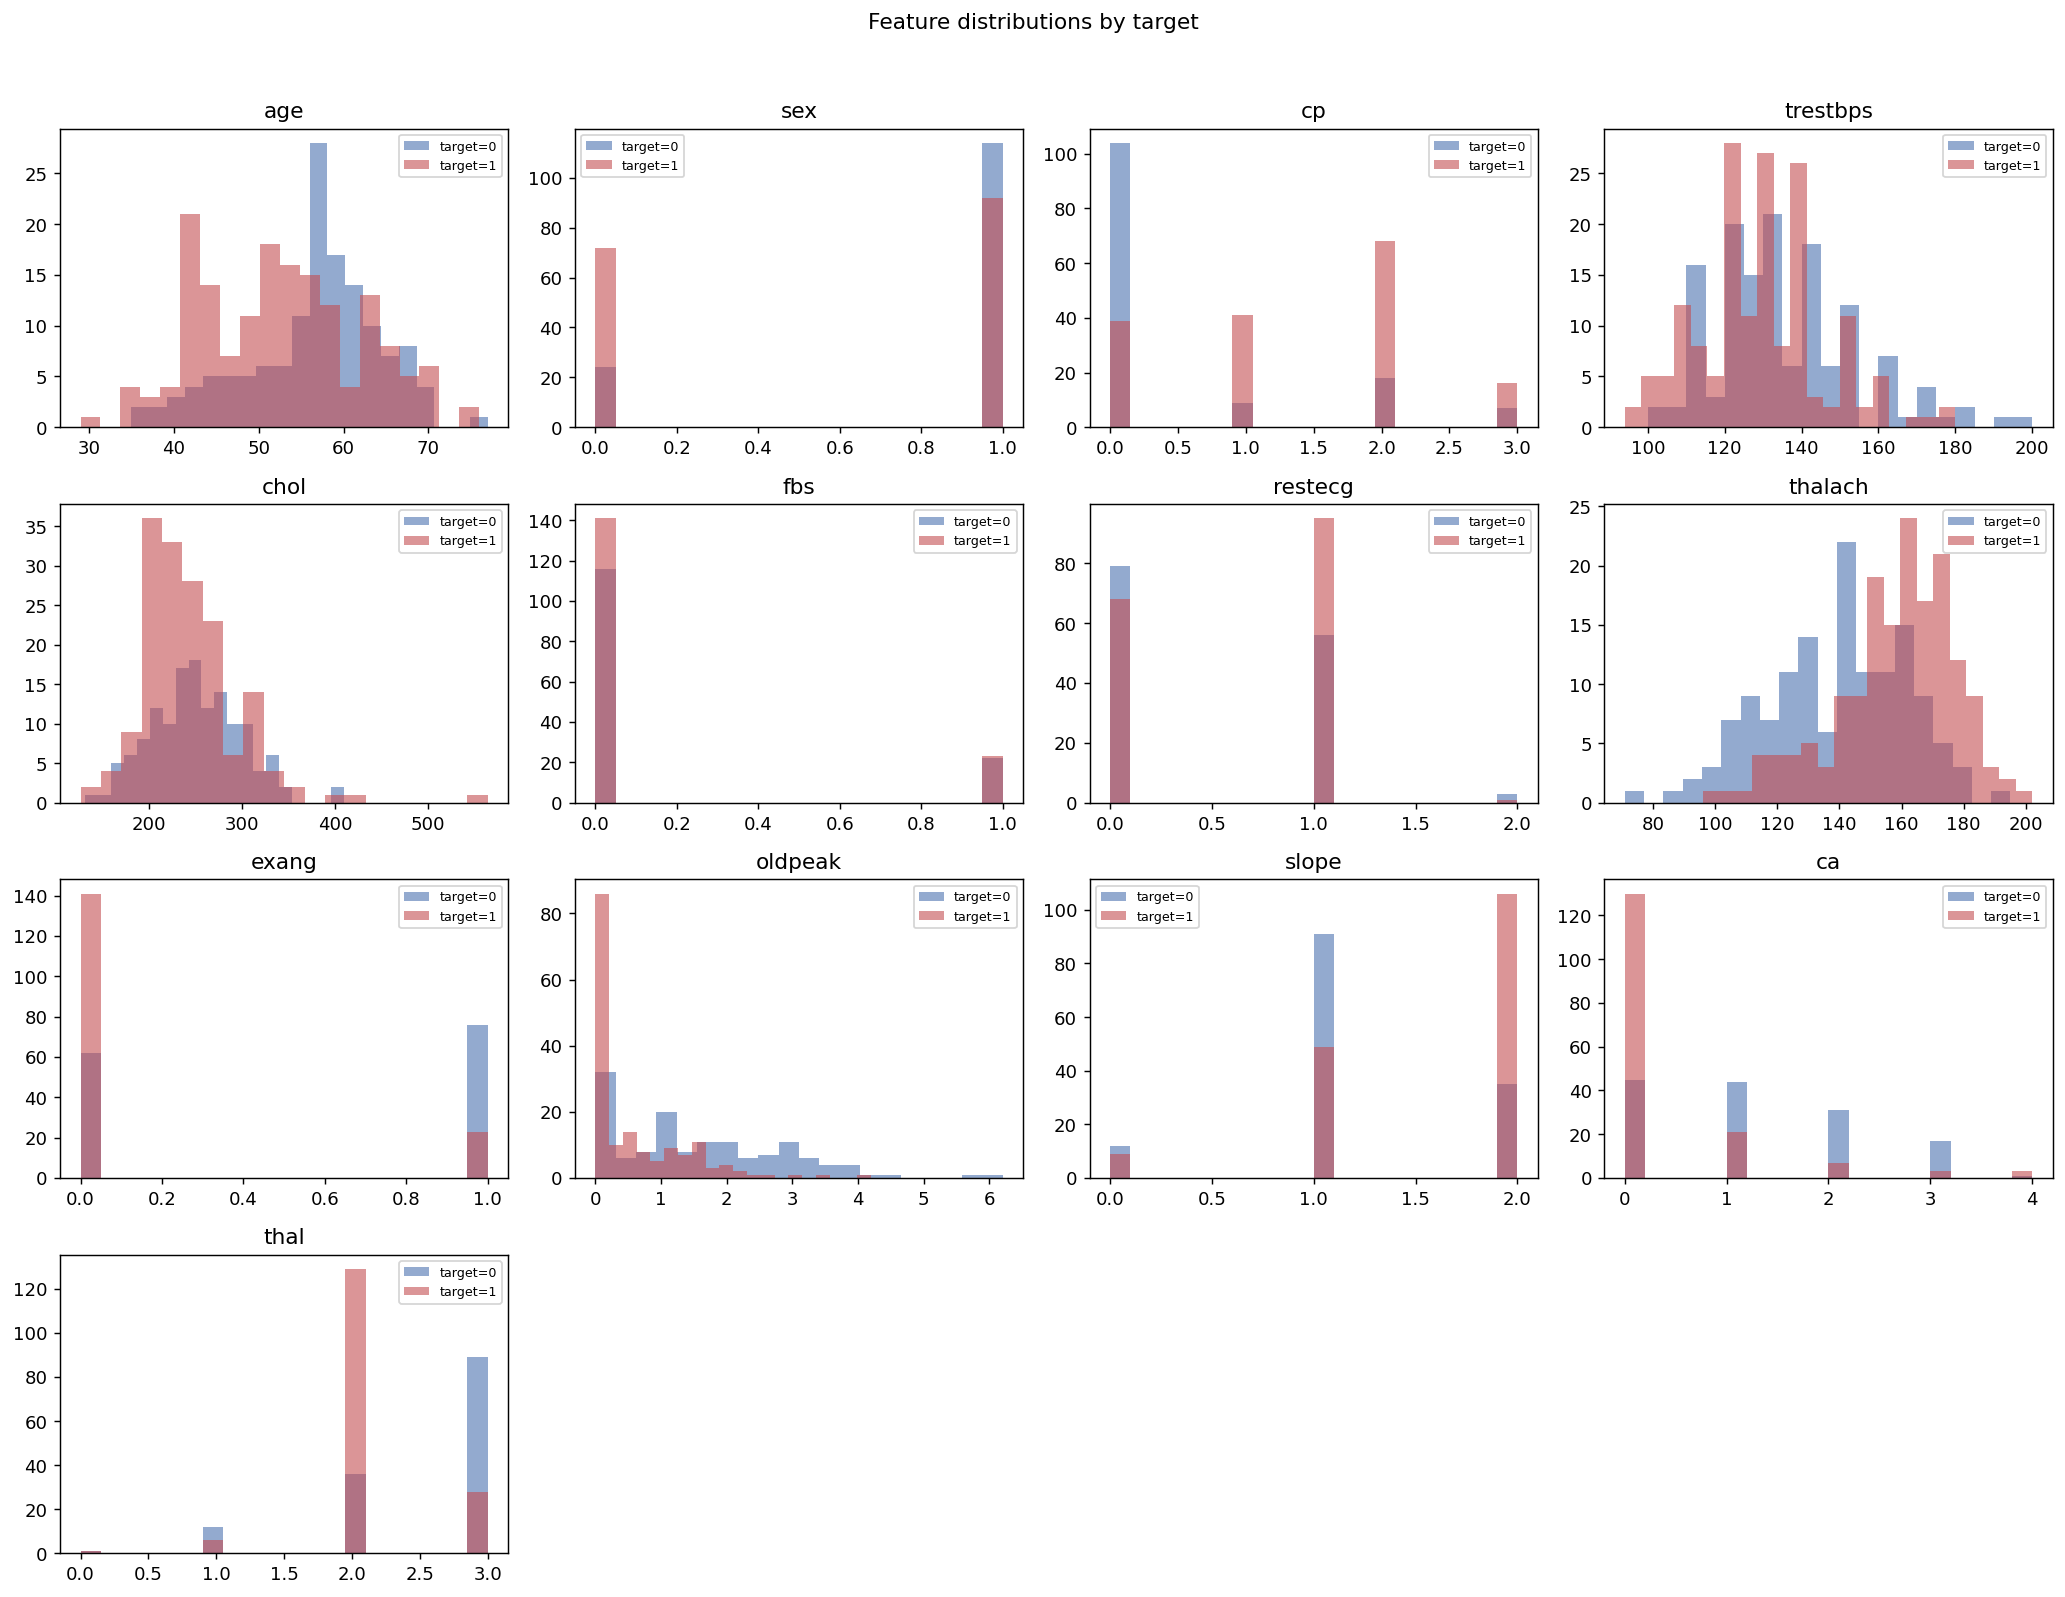

In [69]:
display(Image(plots.plot_feature_histograms(df, feature_names)))

## Duplicates

In [70]:
X_raw, y_raw, _ = dl.get_Xy(raw_df)      # with duplicates
X_unique, y_unique, _ = dl.get_Xy(df)    # without duplicates

experiments = {
    "1-NN":                 (lambda: KNNClassifier(k=1), True),
    "5-NN":                 (lambda: KNNClassifier(k=5), True),
    "Decision Tree (full)": (lambda: DecisionTreeClassifier(max_depth=None), False),
    "Decision Tree (d=4)":  (lambda: DecisionTreeClassifier(max_depth=4), False),
    "AdaBoost (100)":       (lambda: AdaBoostClassifier(n_estimators=100), False),
    "Neural Net":           (lambda: NeuralNetwork(hidden_layers=(16,), activation="relu",
                                                   lr=0.1, epochs=300, batch_size=32,
                                                   l2=1e-4, seed=SEED), True),
}

rows = []
for name, (factory, scale) in experiments.items():
    exp = ev.duplicate_leakage_experiment(
        factory, X_raw, y_raw, X_unique, y_unique, seed=SEED, scale=scale
    )
    rows.append({
        "model":              name,
        "train (dup)":        exp["train_accuracy_with_duplicates"],
        "test (dup)":         exp["accuracy_with_duplicates"],
        "train (dedup)":      exp["train_accuracy_deduplicated"],
        "test (dedup)":       exp["accuracy_deduplicated"],
        "overfit gap":        exp["train_accuracy_deduplicated"] - exp["accuracy_deduplicated"],
        "leakage gap":        exp["accuracy_with_duplicates"] - exp["accuracy_deduplicated"],
    })

leakage_df = pd.DataFrame(rows).set_index("model")
leakage_df


,train (dup),test (dup),train (dedup),test (dedup),overfit gap,leakage gap
model,,,,,,
1-NN,1.000,1.000,1.000,0.770,0.230,0.230
5-NN,0.959,0.873,0.867,0.869,-0.002,0.004
Decision Tree (full),1.000,1.000,1.000,0.787,0.213,0.213
Decision Tree (d=4),0.849,0.820,0.859,0.770,0.088,0.049
AdaBoost (100),0.909,0.873,0.909,0.902,0.007,-0.028
Neural Net,1.000,1.000,0.992,0.754,0.238,0.246


## Splitting the data 

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, seed=SEED, stratify=True
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train balance:", np.bincount(y_train), " Test balance:", np.bincount(y_test))

Train: (241, 13)  Test: (61, 13)
Train balance: [110 131]  Test balance: [28 33]


## Z-score

In [72]:
# Compare train/test accuracy with and without z-score standardization for all models.
quick_models = {
    "k-NN (k=5)":          lambda: KNNClassifier(k=5),
    "Decision Tree (d=4)": lambda: DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "AdaBoost (100)":      lambda: AdaBoostClassifier(n_estimators=100),
    "Neural Net":          lambda: NeuralNetwork(hidden_layers=(16,), activation="relu",
                                                 lr=0.1, epochs=300, batch_size=32,
                                                 l2=1e-4, seed=SEED),
}

quick_rows = []
for name, factory in quick_models.items():
    row = {"model": name}
    for label, X_fit, X_eval in [("scaled", X_train_s, X_test_s),
                                  ("raw",    X_train,   X_test)]:
        model = factory()
        model.fit(X_fit, y_train)
        tr = metrics.accuracy(y_train, model.predict(X_fit))
        te = metrics.accuracy(y_test,  model.predict(X_eval))
        row[f"train ({label})"] = tr
        row[f"test ({label})"]  = te
    quick_rows.append(row)

quick_df = pd.DataFrame(quick_rows).set_index("model")
quick_df


,train (scaled),test (scaled),train (raw),test (raw)
model,,,,
k-NN (k=5),0.867,0.869,0.772,0.705
Decision Tree (d=4),0.859,0.770,0.859,0.770
AdaBoost (100),0.909,0.902,0.909,0.902
Neural Net,0.992,0.754,0.544,0.541


## Model 1 - k-Nearest Neighbors

CV accuracy per k: {1: np.float64(0.768), 3: np.float64(0.776), 5: np.float64(0.796), 7: np.float64(0.801), 9: np.float64(0.796), 11: np.float64(0.809), 15: np.float64(0.809), 21: np.float64(0.792), 31: np.float64(0.792), 41: np.float64(0.788), 51: np.float64(0.784), 61: np.float64(0.776), 71: np.float64(0.797), 81: np.float64(0.793), 91: np.float64(0.776), 111: np.float64(0.776), 131: np.float64(0.751), 151: np.float64(0.701), 181: np.float64(0.544), 211: np.float64(0.544)}
Best k = 11


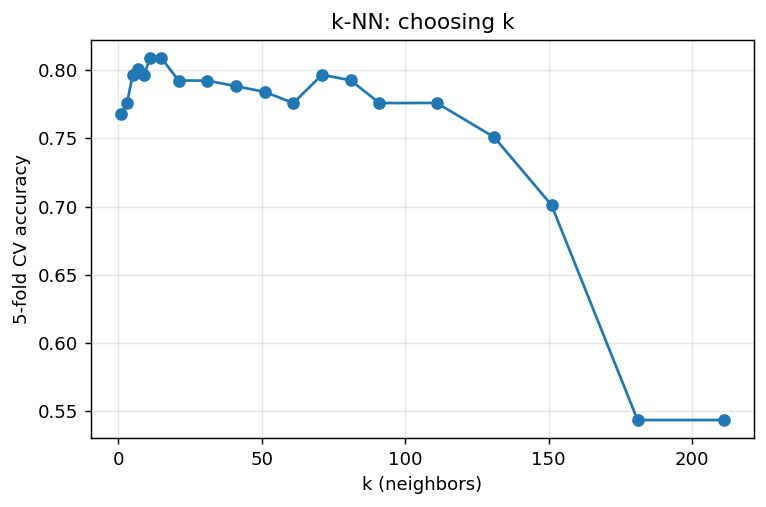

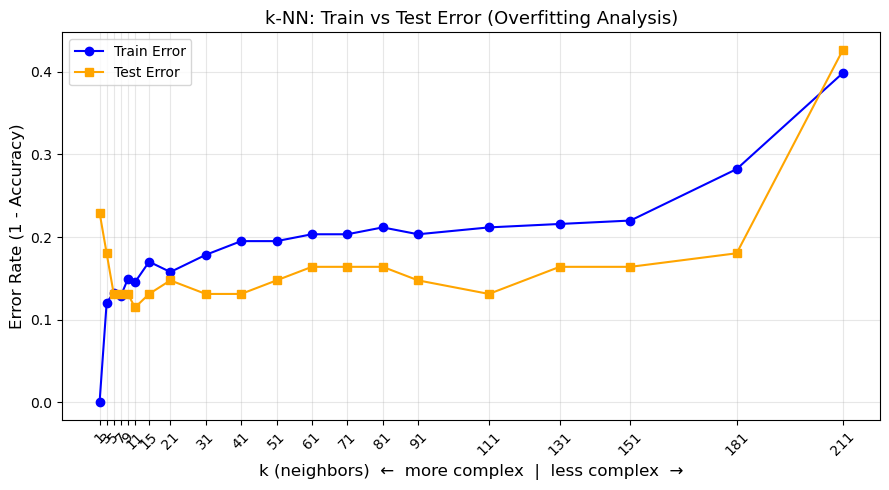

In [73]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 61, 71, 81, 91, 111, 131, 151, 181, 211]
cv_acc = []
for k in k_values:
    scores = ev.cross_val_score(lambda k=k: KNNClassifier(k=k), X_train, y_train,
                                n_splits=5, seed=SEED, scale=True)
    cv_acc.append(scores.mean())

best_k = k_values[int(np.argmax(cv_acc))]
print("CV accuracy per k:", {k: round(a, 3) for k, a in zip(k_values, cv_acc)})
print("Best k =", best_k)
display(Image(plots.plot_curve(k_values, cv_acc, "k (neighbors)",
            "5-fold CV accuracy", "k-NN: choosing k", name="knn_k_curve.png")))

# Train vs Test Error across k values (overfitting analysis).
# k=1 memorises every training point (0 train error, high test error = overfitting).
# As k grows, predictions are smoothed over more neighbours:
#   - train error rises (points get "outvoted" by their neighbours)
#   - test error first falls (less overfitting), then rises again (underfitting / majority vote)
# The U-shape on the test curve reveals the sweet spot.
knn_train_errors = []
knn_test_errors = []
for k in k_values:
    model = KNNClassifier(k=k)
    model.fit(X_train_s, y_train)
    knn_train_errors.append(1.0 - metrics.accuracy(y_train, model.predict(X_train_s)))
    knn_test_errors.append(1.0 - metrics.accuracy(y_test,  model.predict(X_test_s)))

%matplotlib inline
plt.figure(figsize=(9, 5))
plt.plot(k_values, knn_train_errors, marker='o', label='Train Error', color='blue')
plt.plot(k_values, knn_test_errors,  marker='s', label='Test Error',  color='orange')
plt.xlabel('k (neighbors)  ←  more complex  |  less complex  →', fontsize=12)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=12)
plt.title('k-NN: Train vs Test Error (Overfitting Analysis)', fontsize=13)
plt.xticks(k_values, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Model 2 - Decision Tree

Starting Decision Tree grid search — 252 combinations × 5 folds...
  [  1/252] New best: depth=3, min_split=10, min_leaf=3  → acc=0.788 ± 0.015
  [  3/252] New best: depth=3, min_split=10, min_leaf=5  → acc=0.797 ± 0.030
  [ 42/252] ...running  (current best = 0.797)
  [ 45/252] New best: depth=4, min_split=10, min_leaf=5  → acc=0.797 ± 0.039
  [ 57/252] New best: depth=4, min_split=15, min_leaf=5  → acc=0.805 ± 0.027
  [ 84/252] ...running  (current best = 0.805)
  [ 87/252] New best: depth=5, min_split=10, min_leaf=5  → acc=0.805 ± 0.047
  [ 99/252] New best: depth=5, min_split=15, min_leaf=5  → acc=0.813 ± 0.045
  [126/252] ...running  (current best = 0.813)
  [168/252] ...running  (current best = 0.813)
  [210/252] ...running  (current best = 0.813)
  [252/252] ...running  (current best = 0.813)
--------------------------------------------------
Grid search complete.  Best CV accuracy = 0.813 ± 0.045
  max_depth:         5
  min_samples_split: 15
  min_samples_leaf:  5

Final model

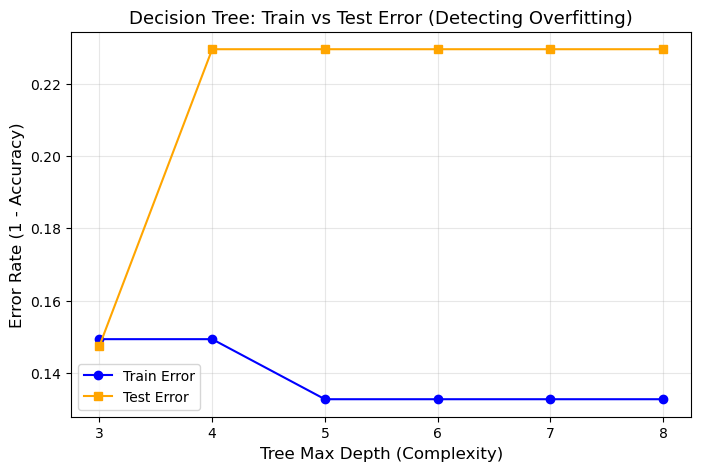

In [74]:
# ── Hyperparameter grid ──────────────────────────────────────────────────────
max_depths         = [3, 4, 5, 6, 7, 8]
min_samples_splits = [10, 12, 15, 18, 20, 25, 30]
min_samples_leaves = [3, 4, 5, 6, 7, 8]

total = len(max_depths) * len(min_samples_splits) * len(min_samples_leaves)

# ── Grid search (5-fold CV) ───────────────────────────────────────────────────
best_accuracy = -np.inf
best_params   = {}
done          = 0

# Dictionaries to store train/test errors for depth analysis
depth_train_errors = {d: [] for d in max_depths}
depth_test_errors  = {d: [] for d in max_depths}

print(f"Starting Decision Tree grid search — {total} combinations × 5 folds...")

for depth in max_depths:
    # To track performance per depth during grid search
    depth_fold_accs = []
    
    for min_split in min_samples_splits:
        for min_leaf in min_samples_leaves:

            scores = ev.cross_val_score(
                lambda d=depth, ms=min_split, ml=min_leaf:
                    DecisionTreeClassifier(max_depth=d, min_samples_split=ms, min_samples_leaf=ml),
                X_train, y_train, n_splits=5, seed=SEED, scale=False,
            )
            avg_accuracy = scores.mean()
            std_accuracy = scores.std()
            done += 1

            # On a tie, prefer the simpler model (smaller depth)
            if avg_accuracy > best_accuracy or (
                avg_accuracy == best_accuracy and depth < best_params["max_depth"]
            ):
                best_accuracy = avg_accuracy
                best_params = {
                    "max_depth":         depth,
                    "min_samples_split": min_split,
                    "min_samples_leaf":  min_leaf,
                    "cv_std":            std_accuracy,
                }
                print(f"  [{done:>3}/{total}] New best: depth={depth}, "
                      f"min_split={min_split}, min_leaf={min_leaf}  "
                      f"→ acc={avg_accuracy:.3f} ± {std_accuracy:.3f}")

            elif done % 42 == 0:
                print(f"  [{done:>3}/{total}] ...running  (current best = {best_accuracy:.3f})")

# ── Extract best parameters ───────────────────────────────────────────────────
best_depth     = best_params["max_depth"]
best_min_split = best_params["min_samples_split"]
best_min_leaf  = best_params["min_samples_leaf"]

print("-" * 50)
print(f"Grid search complete.  Best CV accuracy = {best_accuracy:.3f} ± {best_params['cv_std']:.3f}")
print(f"  max_depth:         {best_depth}")
print(f"  min_samples_split: {best_min_split}")
print(f"  min_samples_leaf:  {best_min_leaf}")

# ── Test-set accuracy for the best hyperparameters ────────────────────────────
dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
).fit(X_train, y_train)
test_acc = metrics.accuracy(y_test, dt_best.predict(X_test))
train_acc = metrics.accuracy(y_train, dt_best.predict(X_train))
print(f"\nFinal model on held-out test set:")
print(f"  Train accuracy = {train_acc:.3f}")
print(f"  Test  accuracy = {test_acc:.3f}  (overfit gap = {train_acc - test_acc:+.3f})")


# ==========================================
# Overfitting Check: Train vs Test Error per Depth
# ==========================================
import matplotlib.pyplot as plt

train_errors = []
test_errors = []

for d in max_depths:
    # Fit a model for each depth using the best split/leaf found for that depth (or overall best)
    tree_d = DecisionTreeClassifier(
        max_depth=d,
        min_samples_split=best_min_split,
        min_samples_leaf=best_min_leaf
    ).fit(X_train, y_train)
    
    train_errors.append(1.0 - metrics.accuracy(y_train, tree_d.predict(X_train)))
    test_errors.append(1.0 - metrics.accuracy(y_test, tree_d.predict(X_test)))

%matplotlib inline
# Plotting the curve directly from the grid search depths
plt.figure(figsize=(8, 5))
plt.plot(max_depths, train_errors, label='Train Error', marker='o', color='blue')
plt.plot(max_depths, test_errors, label='Test Error', marker='s', color='orange')
plt.xlabel('Tree Max Depth (Complexity)', fontsize=12)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=12)
plt.title('Decision Tree: Train vs Test Error (Detecting Overfitting)', fontsize=13)
plt.xticks(max_depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Baseline (all 13 features): CV acc = 0.813

  top- 1 features -> CV acc = 0.768 ± 0.053
  top- 2 features -> CV acc = 0.722 ± 0.062
  top- 3 features -> CV acc = 0.826 ± 0.025
  top- 4 features -> CV acc = 0.801 ± 0.038
  top- 5 features -> CV acc = 0.801 ± 0.038
  top- 6 features -> CV acc = 0.813 ± 0.034
  top- 7 features -> CV acc = 0.813 ± 0.034
  top- 8 features -> CV acc = 0.793 ± 0.022
  top- 9 features -> CV acc = 0.813 ± 0.043
  top-10 features -> CV acc = 0.813 ± 0.045
  top-11 features -> CV acc = 0.813 ± 0.045
  top-12 features -> CV acc = 0.813 ± 0.045
  top-13 features -> CV acc = 0.813 ± 0.045
--------------------------------------------------
Best: top-3 features -> CV acc = 0.826 (baseline = 0.813, gain = +0.012)
Selected features: ['cp', 'ca', 'slope']

Test accuracy — all features:      0.770
Test accuracy — selected features: 0.787  (change: +0.016)


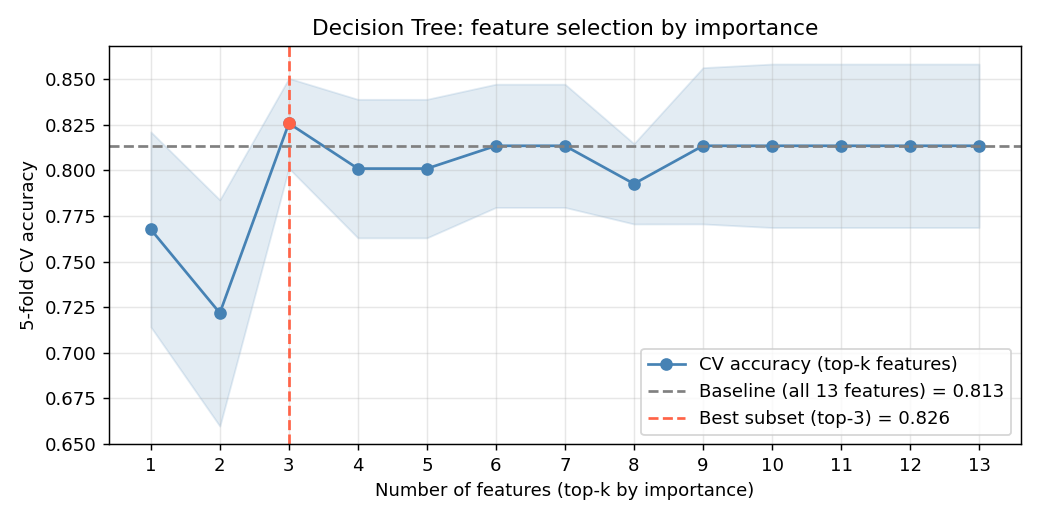

In [75]:

# ── Feature selection by importance (try to improve the Decision Tree) ────────
# Fit a tree with the tuned hyperparameters on all features to rank them.
base_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
).fit(X_train, y_train)
importance_order = np.argsort(base_tree.feature_importances_)[::-1]  # most important first

# Baseline: 5-fold CV accuracy using all features.
baseline_acc = ev.cross_val_score(
    lambda: DecisionTreeClassifier(max_depth=best_depth,
                                   min_samples_split=best_min_split,
                                   min_samples_leaf=best_min_leaf),
    X_train, y_train, n_splits=5, seed=SEED, scale=False,
).mean()
print(f"Baseline (all {X_train.shape[1]} features): CV acc = {baseline_acc:.3f}\n")

# Greedily add features in importance order; keep the subset with the best CV accuracy.
selection_results = []
for k in range(1, len(importance_order) + 1):
    cols = importance_order[:k]
    scores = ev.cross_val_score(
        lambda: DecisionTreeClassifier(max_depth=best_depth,
                                       min_samples_split=best_min_split,
                                       min_samples_leaf=best_min_leaf),
        X_train[:, cols], y_train, n_splits=5, seed=SEED, scale=False,
    )
    selection_results.append({"k": k, "cv_acc": scores.mean(), "cv_std": scores.std()})
    print(f"  top-{k:>2} features -> CV acc = {scores.mean():.3f} ± {scores.std():.3f}")

# ── Pick the best subset ──────────────────────────────────────────────────────
sel_df = pd.DataFrame(selection_results)
best_n_feats = int(sel_df.loc[sel_df["cv_acc"].idxmax(), "k"])
selected_features = importance_order[:best_n_feats]
selected_acc = sel_df["cv_acc"].max()

print("-" * 50)
print(f"Best: top-{best_n_feats} features -> CV acc = {selected_acc:.3f} "
      f"(baseline = {baseline_acc:.3f}, gain = {selected_acc - baseline_acc:+.3f})")
print("Selected features:", [feature_names[i] for i in selected_features])

# ── Final check on the held-out test set ──────────────────────────────────────
dt_selected = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
).fit(X_train[:, selected_features], y_train)
test_acc_sel = metrics.accuracy(y_test, dt_selected.predict(X_test[:, selected_features]))
dt_base_test_acc = metrics.accuracy(y_test, base_tree.predict(X_test))
print(f"\nTest accuracy — all features:      {dt_base_test_acc:.3f}")
print(f"Test accuracy — selected features: {test_acc_sel:.3f}  (change: {test_acc_sel - dt_base_test_acc:+.3f})")

# ── Plot CV accuracy vs number of features ────────────────────────────────────
import matplotlib.pyplot as plt

ks       = sel_df["k"].tolist()
cv_accs  = sel_df["cv_acc"].tolist()
cv_stds  = sel_df["cv_std"].tolist()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, cv_accs, marker="o", color="steelblue", label="CV accuracy (top-k features)")
ax.fill_between(ks,
                [a - s for a, s in zip(cv_accs, cv_stds)],
                [a + s for a, s in zip(cv_accs, cv_stds)],
                alpha=0.15, color="steelblue")
ax.axhline(baseline_acc, color="gray",   linestyle="--", label=f"Baseline (all {len(ks)} features) = {baseline_acc:.3f}")
ax.axvline(best_n_feats, color="tomato", linestyle="--", label=f"Best subset (top-{best_n_feats}) = {selected_acc:.3f}")
ax.scatter([best_n_feats], [selected_acc], color="tomato", zorder=5)
ax.set_xlabel("Number of features (top-k by importance)")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Decision Tree: feature selection by importance")
ax.set_xticks(ks)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/dt_feature_selection.png", dpi=130)
plt.close(fig)
display(Image("../figures/dt_feature_selection.png"))


## Model 3 - AdaBoost

--- AdaBoost Results (Train vs Test Error Tracking) ---
n_estimators=  1 | Train Error: 0.232 | Test Error: 0.279 | gap: -0.046
n_estimators=  5 | Train Error: 0.166 | Test Error: 0.148 | gap: 0.018
n_estimators= 10 | Train Error: 0.149 | Test Error: 0.213 | gap: -0.064
n_estimators= 20 | Train Error: 0.137 | Test Error: 0.115 | gap: 0.022
n_estimators= 30 | Train Error: 0.129 | Test Error: 0.115 | gap: 0.014
n_estimators= 50 | Train Error: 0.116 | Test Error: 0.131 | gap: -0.015
n_estimators= 75 | Train Error: 0.104 | Test Error: 0.098 | gap: 0.005
n_estimators=100 | Train Error: 0.091 | Test Error: 0.098 | gap: -0.007


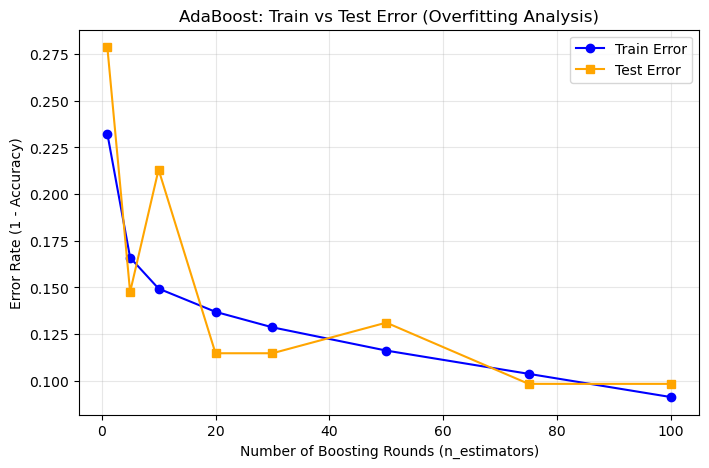


CV accuracy per n_estimators: {1: np.float64(0.768), 5: np.float64(0.788), 10: np.float64(0.805), 20: np.float64(0.793), 30: np.float64(0.793), 50: np.float64(0.784), 75: np.float64(0.772), 100: np.float64(0.768)}
Best n_estimators = 10
Test accuracy (n_estimators=10) = 0.787


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from src.models.adaboost import AdaBoostClassifier
from src import metrics, evaluation as ev

# List of rounds to evaluate
rounds_list = [1, 5, 10, 20, 30, 50, 75, 100]
train_errors = []
test_errors = []

print("--- AdaBoost Results (Train vs Test Error Tracking) ---")
for n in rounds_list:
    # Train model with n boosting rounds
    ada_model = AdaBoostClassifier(n_estimators=n)
    ada_model.fit(X_train, y_train)
    
    # Compute error (1 - Accuracy) on train and test sets
    tr_err = 1.0 - metrics.accuracy(y_train, ada_model.predict(X_train))
    te_err = 1.0 - metrics.accuracy(y_test, ada_model.predict(X_test))
    
    train_errors.append(tr_err)
    test_errors.append(te_err)
    
    print(f"n_estimators={n:3d} | Train Error: {tr_err:.3f} | Test Error: {te_err:.3f} | gap: {tr_err - te_err:.3f}")

# Plot train error vs test error by number of boosting rounds
plt.figure(figsize=(8, 5))
plt.plot(rounds_list, train_errors, marker='o', label='Train Error', color='blue')
plt.plot(rounds_list, test_errors, marker='s', label='Test Error', color='orange')
plt.xlabel('Number of Boosting Rounds (n_estimators)')
plt.ylabel('Error Rate (1 - Accuracy)')
plt.title('AdaBoost: Train vs Test Error (Overfitting Analysis)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Select the best number of rounds using 5-fold CV
round_grid = [1, 5, 10, 20, 30, 50, 75, 100]
cv_round = []
for n_rounds in round_grid:
    scores = ev.cross_val_score(lambda n=n_rounds: AdaBoostClassifier(n_estimators=n),
                                X_train, y_train, n_splits=5, seed=SEED, scale=False)
    cv_round.append(scores.mean())
best_n_rounds = round_grid[int(np.argmax(cv_round))]
print("\nCV accuracy per n_estimators:", {n: round(acc, 3) for n, acc in zip(round_grid, cv_round)})
print("Best n_estimators =", best_n_rounds)

# Final test accuracy for the best model
best_ada = AdaBoostClassifier(n_estimators=best_n_rounds)
best_ada.fit(X_train, y_train)
print(f"Test accuracy (n_estimators={best_n_rounds}) = {metrics.accuracy(y_test, best_ada.predict(X_test)):.3f}")


Baseline (all 13 features): CV acc = 0.805

  top- 1 features -> CV acc = 0.768 ± 0.053
  top- 2 features -> CV acc = 0.743 ± 0.047
  top- 3 features -> CV acc = 0.838 ± 0.020
  top- 4 features -> CV acc = 0.813 ± 0.022
  top- 5 features -> CV acc = 0.805 ± 0.043
  top- 6 features -> CV acc = 0.813 ± 0.051
  top- 7 features -> CV acc = 0.809 ± 0.039
  top- 8 features -> CV acc = 0.818 ± 0.047
  top- 9 features -> CV acc = 0.805 ± 0.056
  top-10 features -> CV acc = 0.822 ± 0.051
  top-11 features -> CV acc = 0.801 ± 0.033
  top-12 features -> CV acc = 0.805 ± 0.036
  top-13 features -> CV acc = 0.805 ± 0.036
--------------------------------------------------
Best: top-3 features -> CV acc = 0.838 (baseline = 0.805, gain = +0.033)
Selected features: ['cp', 'ca', 'slope']

Test accuracy — all features:      0.787
Test accuracy — selected features: 0.787  (change: +0.000)


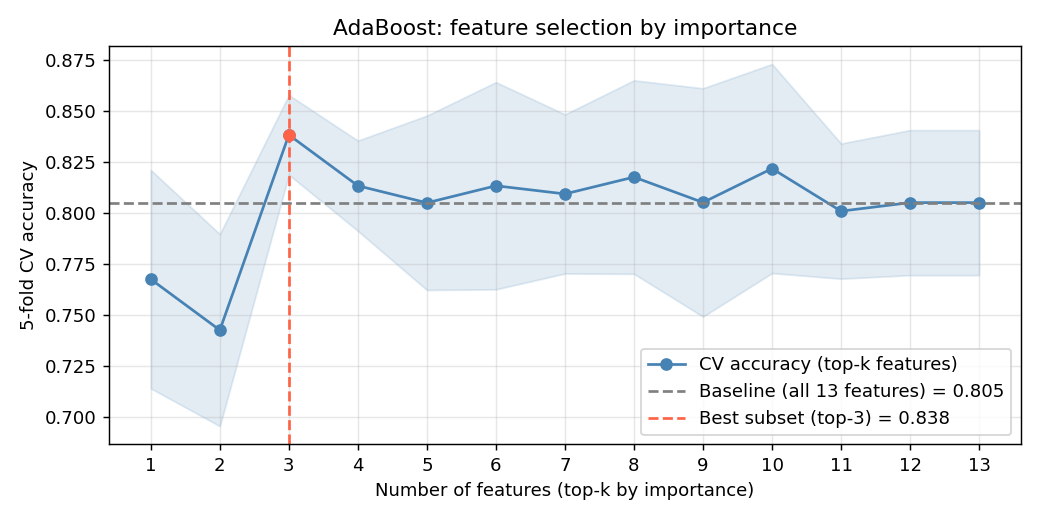

In [77]:

# ── Feature selection by importance (try to improve AdaBoost) ────────
# Fit an AdaBoost model with the tuned n_estimators to rank features.
base_ada = AdaBoostClassifier(n_estimators=best_n_rounds)
base_ada.fit(X_train, y_train)
ada_importance_order = np.argsort(base_ada.feature_importances_)[::-1]  # most important first

# Baseline: 5-fold CV accuracy using all features.
ada_baseline_acc = ev.cross_val_score(
    lambda: AdaBoostClassifier(n_estimators=best_n_rounds),
    X_train, y_train, n_splits=5, seed=SEED, scale=False,
).mean()
print(f"Baseline (all {X_train.shape[1]} features): CV acc = {ada_baseline_acc:.3f}\n")

# Greedily add features in importance order; keep the subset with the best CV accuracy.
ada_selection_results = []
for k in range(1, len(ada_importance_order) + 1):
    cols = ada_importance_order[:k]
    scores = ev.cross_val_score(
        lambda c=cols: AdaBoostClassifier(n_estimators=best_n_rounds),
        X_train[:, cols], y_train, n_splits=5, seed=SEED, scale=False,
    )
    ada_selection_results.append({"k": k, "cv_acc": scores.mean(), "cv_std": scores.std()})
    print(f"  top-{k:>2} features -> CV acc = {scores.mean():.3f} ± {scores.std():.3f}")

# ── Pick the best subset ──────────────────────────────────────────────────────
ada_sel_df = pd.DataFrame(ada_selection_results)
ada_best_n_feats = int(ada_sel_df.loc[ada_sel_df["cv_acc"].idxmax(), "k"])
ada_selected_features = ada_importance_order[:ada_best_n_feats]
ada_selected_acc = ada_sel_df["cv_acc"].max()

print("-" * 50)
print(f"Best: top-{ada_best_n_feats} features -> CV acc = {ada_selected_acc:.3f} "
      f"(baseline = {ada_baseline_acc:.3f}, gain = {ada_selected_acc - ada_baseline_acc:+.3f})")
print("Selected features:", [feature_names[i] for i in ada_selected_features])

# ── Final check on the held-out test set ──────────────────────────────────────
ada_selected_model = AdaBoostClassifier(n_estimators=best_n_rounds).fit(
    X_train[:, ada_selected_features], y_train
)
ada_test_acc_sel = metrics.accuracy(y_test, ada_selected_model.predict(X_test[:, ada_selected_features]))
ada_base_test_acc = metrics.accuracy(y_test, base_ada.predict(X_test))
print(f"\nTest accuracy — all features:      {ada_base_test_acc:.3f}")
print(f"Test accuracy — selected features: {ada_test_acc_sel:.3f}  (change: {ada_test_acc_sel - ada_base_test_acc:+.3f})")

# ── Plot CV accuracy vs number of features ────────────────────────────────────
ks      = ada_sel_df["k"].tolist()
cv_accs = ada_sel_df["cv_acc"].tolist()
cv_stds = ada_sel_df["cv_std"].tolist()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, cv_accs, marker="o", color="steelblue", label="CV accuracy (top-k features)")
ax.fill_between(ks,
                [a - s for a, s in zip(cv_accs, cv_stds)],
                [a + s for a, s in zip(cv_accs, cv_stds)],
                alpha=0.15, color="steelblue")
ax.axhline(ada_baseline_acc, color="gray",   linestyle="--",
           label=f"Baseline (all {len(ks)} features) = {ada_baseline_acc:.3f}")
ax.axvline(ada_best_n_feats, color="tomato", linestyle="--",
           label=f"Best subset (top-{ada_best_n_feats}) = {ada_selected_acc:.3f}")
ax.scatter([ada_best_n_feats], [ada_selected_acc], color="tomato", zorder=5)
ax.set_xlabel("Number of features (top-k by importance)")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("AdaBoost: feature selection by importance")
ax.set_xticks(ks)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/ada_feature_selection.png", dpi=130)
plt.close(fig)
display(Image("../figures/ada_feature_selection.png"))


## Model 4 - Neural Network

Numerical gradient check (relative diff) = 5.02e-10  -> PASS
hidden_layers    lr    l2  cv_acc  cv_std
        (64,) 0.100 0.000   0.801   0.051
     (32, 16) 0.100 0.000   0.793   0.013
         (8,) 0.100 0.000   0.780   0.066
        (32,) 0.100 0.000   0.780   0.049
        (16,) 0.100 0.000   0.772   0.054
        (16,) 0.100 0.001   0.772   0.054
        (16,) 0.100 0.000   0.772   0.054
      (16, 8) 0.100 0.000   0.764   0.075
        (16,) 0.010 0.000   0.759   0.062

Best params: {'hidden_layers': (64,), 'lr': 0.1, 'l2': 0.0001}
Best CV accuracy = 0.801 ± 0.051

Stopped at epoch 26  (best epoch = 5)
Final training loss = 0.2752
Test accuracy       = 0.852


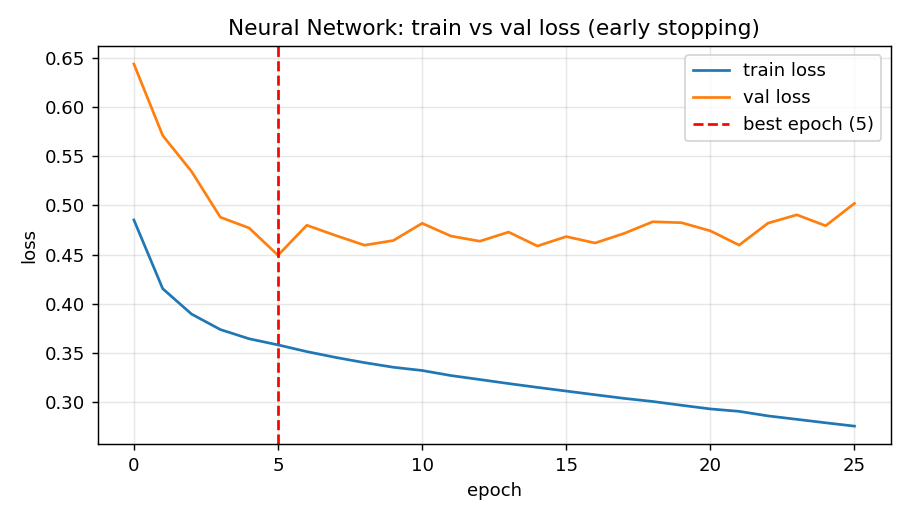

epochs= 10 | Train Error: 0.137 | Test Error: 0.098
epochs= 25 | Train Error: 0.100 | Test Error: 0.131
epochs= 50 | Train Error: 0.062 | Test Error: 0.131
epochs=100 | Train Error: 0.029 | Test Error: 0.131
epochs=200 | Train Error: 0.008 | Test Error: 0.164
epochs=300 | Train Error: 0.000 | Test Error: 0.164
epochs=400 | Train Error: 0.000 | Test Error: 0.164
epochs=500 | Train Error: 0.000 | Test Error: 0.164


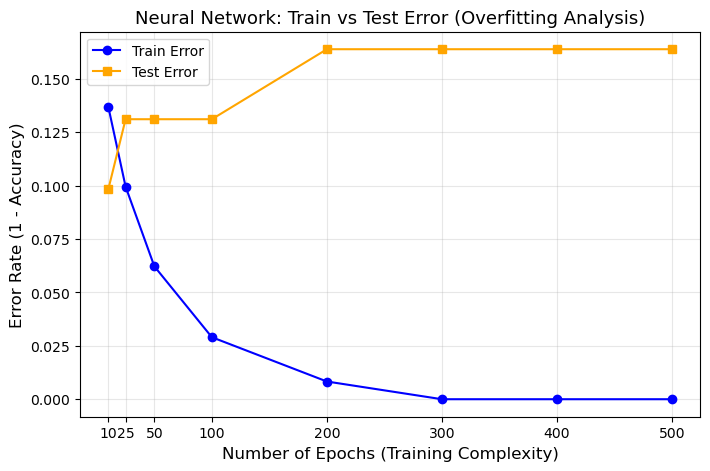

In [78]:

# Verify back-propagation with a numerical gradient check.
grad_diff = NeuralNetwork(hidden_layers=(8,), seed=0).gradient_check(X_train_s[:20], y_train[:20])
print(f"Numerical gradient check (relative diff) = {grad_diff:.2e}  -> {'PASS' if grad_diff < 1e-5 else 'FAIL'}")

# Hyperparameter search over architecture, learning rate, and L2 regularization.
param_grid = [
    {"hidden_layers": (8,),      "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (16,),     "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (32,),     "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (64,),     "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (16, 8),   "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (32, 16),  "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (16,),     "lr": 0.01, "l2": 1e-4},
    {"hidden_layers": (16,),     "lr": 0.1,  "l2": 1e-3},
    {"hidden_layers": (16,),     "lr": 0.1,  "l2": 1e-5},
]

nn_cv_results = []
for params in param_grid:
    scores = ev.cross_val_score(
        lambda p=params: NeuralNetwork(hidden_layers=p["hidden_layers"], activation="relu",
                                       lr=p["lr"], epochs=500, batch_size=32,
                                       l2=p["l2"], seed=SEED,
                                       patience=20, val_fraction=0.1),
        X_train_s, y_train, n_splits=5, seed=SEED, scale=False
    )
    nn_cv_results.append({**params, "cv_acc": scores.mean(), "cv_std": scores.std()})

nn_cv_df = pd.DataFrame(nn_cv_results).sort_values("cv_acc", ascending=False)
nn_cv_df["hidden_layers"] = nn_cv_df["hidden_layers"].astype(str)
print(nn_cv_df.to_string(index=False))

# Selection: best cv_acc; ties broken by complexity (fewer/smaller layers) then cv_std.
best_acc = max(r["cv_acc"] for r in nn_cv_results)
candidates = [r for r in nn_cv_results if r["cv_acc"] == best_acc]
best_nn_params = min(candidates, key=lambda r: (sum(r["hidden_layers"]), r["cv_std"]))

print("\nBest params:", {k: v for k, v in best_nn_params.items() if k not in ("cv_acc", "cv_std")})
print("Best CV accuracy = %.3f ± %.3f" % (best_nn_params["cv_acc"], best_nn_params["cv_std"]))

# Train final network with early stopping (up to 500 epochs, stop if no val improvement for 20).
nn = NeuralNetwork(hidden_layers=best_nn_params["hidden_layers"], activation="relu",
                   lr=best_nn_params["lr"], epochs=500, batch_size=32,
                   l2=best_nn_params["l2"], seed=SEED,
                   patience=20, val_fraction=0.1)
nn.fit(X_train_s, y_train)
print(f"\nStopped at epoch {len(nn.loss_history_)}  (best epoch = {nn.best_epoch_})")
print("Final training loss = %.4f" % nn.loss_history_[-1])
print("Test accuracy       = %.3f" % metrics.accuracy(y_test, nn.predict(X_test_s)))

# Plot train and validation loss together to visualise early stopping.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nn.loss_history_,     label="train loss")
ax.plot(nn.val_loss_history_, label="val loss")
ax.axvline(nn.best_epoch_, color="red", linestyle="--", label=f"best epoch ({nn.best_epoch_})")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Neural Network: train vs val loss (early stopping)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/nn_loss_curve.png", dpi=130)
plt.close(fig)
display(Image("../figures/nn_loss_curve.png"))

# Train vs Test Error across epoch counts (overfitting analysis).
# More epochs = higher model complexity; shows when the network starts to overfit.
epoch_list = [10, 25, 50, 100, 200, 300, 400, 500]
nn_train_errors = []
nn_test_errors  = []
for ep in epoch_list:
    m = NeuralNetwork(hidden_layers=best_nn_params["hidden_layers"], activation="relu",
                      lr=best_nn_params["lr"], epochs=ep, batch_size=32,
                      l2=best_nn_params["l2"], seed=SEED)
    m.fit(X_train_s, y_train)
    nn_train_errors.append(1.0 - metrics.accuracy(y_train, m.predict(X_train_s)))
    nn_test_errors.append(1.0 - metrics.accuracy(y_test,  m.predict(X_test_s)))
    print(f"epochs={ep:>3d} | Train Error: {nn_train_errors[-1]:.3f} | Test Error: {nn_test_errors[-1]:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(epoch_list, nn_train_errors, marker='o', label='Train Error', color='blue')
plt.plot(epoch_list, nn_test_errors,  marker='s', label='Test Error',  color='orange')
plt.xlabel('Number of Epochs (Training Complexity)', fontsize=12)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=12)
plt.title('Neural Network: Train vs Test Error (Overfitting Analysis)', fontsize=13)
plt.xticks(epoch_list)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 10. Model comparison

In [79]:

# Final tuned models — Decision Tree and AdaBoost use their selected feature subsets.
final_models = {
    "k-NN":          (lambda: KNNClassifier(k=best_k), True, None),
    "Decision Tree": (lambda: DecisionTreeClassifier(max_depth=best_depth,
                                                      min_samples_split=best_min_split,
                                                      min_samples_leaf=best_min_leaf), False, selected_features),
    "AdaBoost":      (lambda: AdaBoostClassifier(n_estimators=best_n_rounds), False, ada_selected_features),
    "Neural Net":    (lambda: NeuralNetwork(hidden_layers=best_nn_params["hidden_layers"],
                                            activation="relu",
                                            lr=best_nn_params["lr"], epochs=500,
                                            batch_size=32, l2=best_nn_params["l2"],
                                            seed=SEED, patience=20, val_fraction=0.1), True, None),
}

results = {}
fitted = {}
for name, (factory, scale, cols) in final_models.items():
    X_fit, X_eval = (X_train_s, X_test_s) if scale else (X_train, X_test)
    if cols is not None:
        X_fit, X_eval = X_fit[:, cols], X_eval[:, cols]
    model = factory()
    model.fit(X_fit, y_train)
    fitted[name] = (model, scale, cols)
    results[name] = ev.evaluate_model(model, X_fit, y_train, X_eval, y_test)

results_df = pd.DataFrame(results).T[["train_accuracy", "accuracy"]]
results_df.columns = ["train acc", "test acc"]
results_df["overfit gap"] = results_df["train acc"] - results_df["test acc"]
results_df = results_df.sort_values("test acc", ascending=False)

results_df


,train acc,test acc,overfit gap
k-NN,0.855,0.885,-0.030
Neural Net,0.842,0.852,-0.010
Decision Tree,0.838,0.787,0.051
AdaBoost,0.838,0.787,0.051


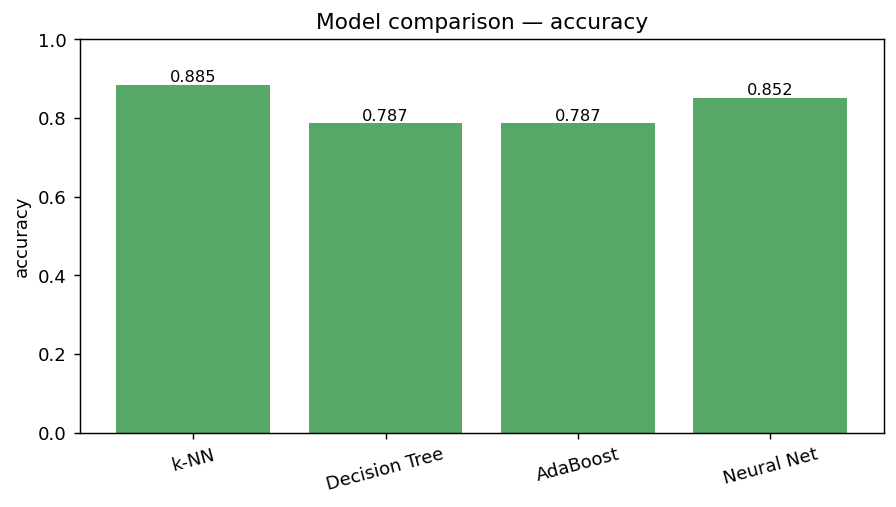

Best model: k-NN (test acc = 0.885, train acc = 0.855)


In [80]:
display(Image(plots.plot_model_comparison(results, metric="accuracy")))
best_name = results_df.index[0]
print("Best model:", best_name, "(test acc = %.3f, train acc = %.3f)" % (
    results_df.loc[best_name, "test acc"], results_df.loc[best_name, "train acc"]))


## 11. Feature importance (research question 3)

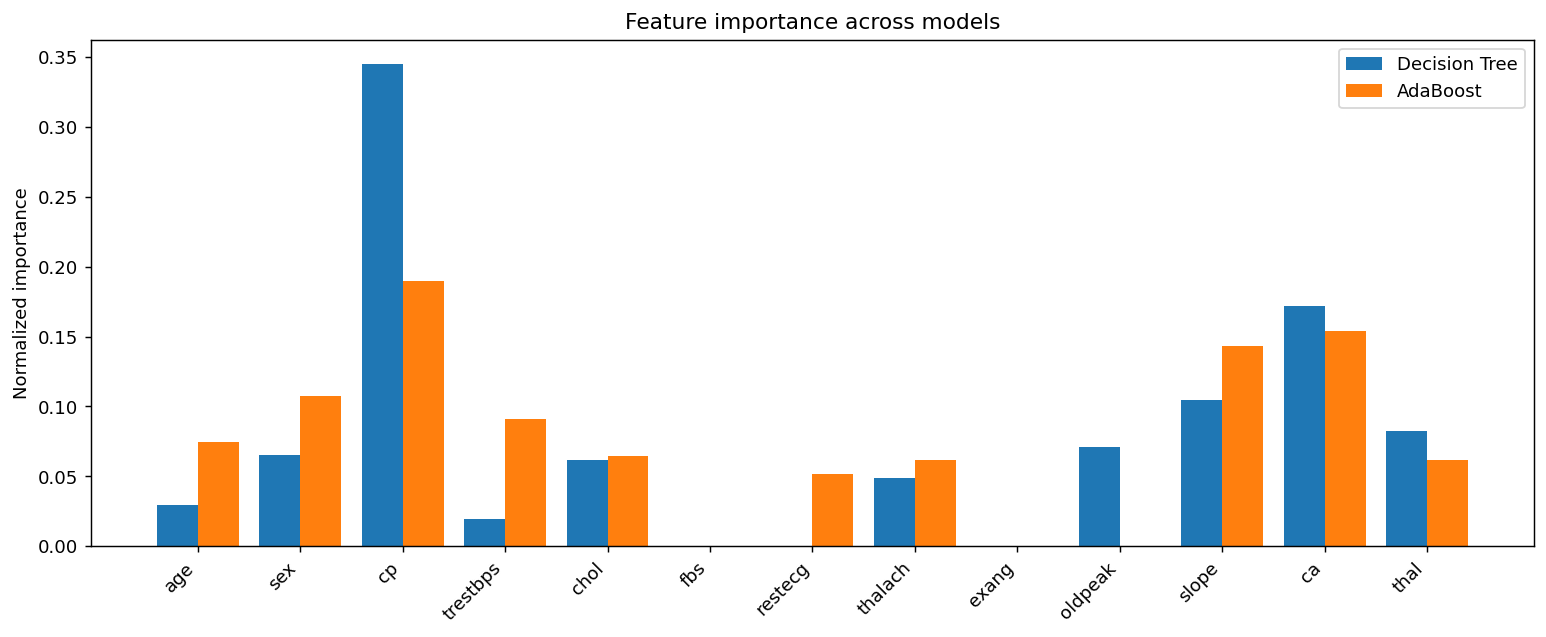

,Decision Tree,AdaBoost,mean
cp,0.345,0.190,0.268
ca,0.172,0.154,0.163
slope,0.105,0.143,0.124
sex,0.065,0.107,0.086
thal,0.082,0.062,0.072
chol,0.062,0.065,0.063
trestbps,0.020,0.091,0.055
thalach,0.049,0.062,0.055
age,0.030,0.074,0.052
oldpeak,0.071,0.000,0.035


In [81]:

importances = {}

# Decision Tree: fitted on all features — no zeroing out.
importances["Decision Tree"] = base_tree.feature_importances_

# AdaBoost: fitted on all features — no zeroing out.
importances["AdaBoost"] = base_ada.feature_importances_

display(Image(plots.plot_feature_importances(importances, feature_names)))

# Average the normalized importances across models to get a consensus.
normalized = {}
for model_name, importance in importances.items():
    importance = np.asarray(importance)
    normalized[model_name] = importance / (np.sum(np.abs(importance)) or 1)

imp_df = pd.DataFrame(normalized, index=feature_names)

imp_df["mean"] = imp_df.mean(axis=1)
imp_df.sort_values("mean", ascending=False)
